<a href="https://colab.research.google.com/github/AVarshitha/task3_insta_analysis/blob/main/insta_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Data analysis libraries loaded successfully.")

Data analysis libraries loaded successfully.


In [3]:
# Load the relevant data sheets
photos_df = pd.read_csv('photos.csv')
likes_df = pd.read_csv('likes.csv')
comments_df = pd.read_csv('comments.csv')

# Standardize column header strings to lowercase and strip spaces
photos_df.columns = photos_df.columns.str.strip().str.lower()
likes_df.columns = likes_df.columns.str.strip().str.lower()
comments_df.columns = comments_df.columns.str.strip().str.lower()

# Dynamically find the photo ID column in each file to avoid KeyErrors
photo_id_photos = [c for c in photos_df.columns if 'photo' in c or 'id' in c][0]
photo_id_likes = [c for c in likes_df.columns if 'photo' in c or 'id' in c][0]
photo_id_comments = [c for c in comments_df.columns if 'photo' in c or 'id' in c][0]

print(f"Mapping columns found -> Photos: '{photo_id_photos}', Likes: '{photo_id_likes}', Comments: '{photo_id_comments}'")

# 1. Map total likes per post
likes_per_post = likes_df.groupby(photo_id_likes).size().reset_index(name='like_count')
likes_per_post.rename(columns={photo_id_likes: 'merge_id'}, inplace=True)

# 2. Map total comments per post
comments_per_post = comments_df.groupby(photo_id_comments).size().reset_index(name='comment_count')
comments_per_post.rename(columns={photo_id_comments: 'merge_id'}, inplace=True)

# Prepare photos dataframe for merging
photos_df = photos_df.rename(columns={photo_id_photos: 'merge_id'})

# 3. Merge metrics into unified framework
df = pd.merge(photos_df, likes_per_post, on='merge_id', how='left')
df = pd.merge(df, comments_per_post, on='merge_id', how='left')

# Fill empty posts with 0 engagement
df['like_count'] = df['like_count'].fillna(0)
df['comment_count'] = df['comment_count'].fillna(0)
df['total_engagement'] = df['like_count'] + df['comment_count']

print(f"Data successfully merged. Total posts analyzed: {df.shape[0]}")

Mapping columns found -> Photos: 'id', Likes: 'photo', Comments: 'id'
Data successfully merged. Total posts analyzed: 257


In [4]:
# Find the exact timestamp column name dynamically
date_col = [c for c in df.columns if 'date' in c or 'time' in c or 'created' in c][0]

# Convert strings to datetime objects
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[date_col])

# Feature engineering time dimensions
df['hour'] = df[date_col].dt.hour
df['day_of_week'] = df[date_col].dt.day_name()

print("Time features parsed and ready for scheduling metrics.")

Time features parsed and ready for scheduling metrics.


/tmp/ipykernel_7262/1233831166.py:5: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')


/tmp/ipykernel_7262/2003525596.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df, x='day_of_week', y='total_engagement', order=day_order, palette='magma', errorbar=None)


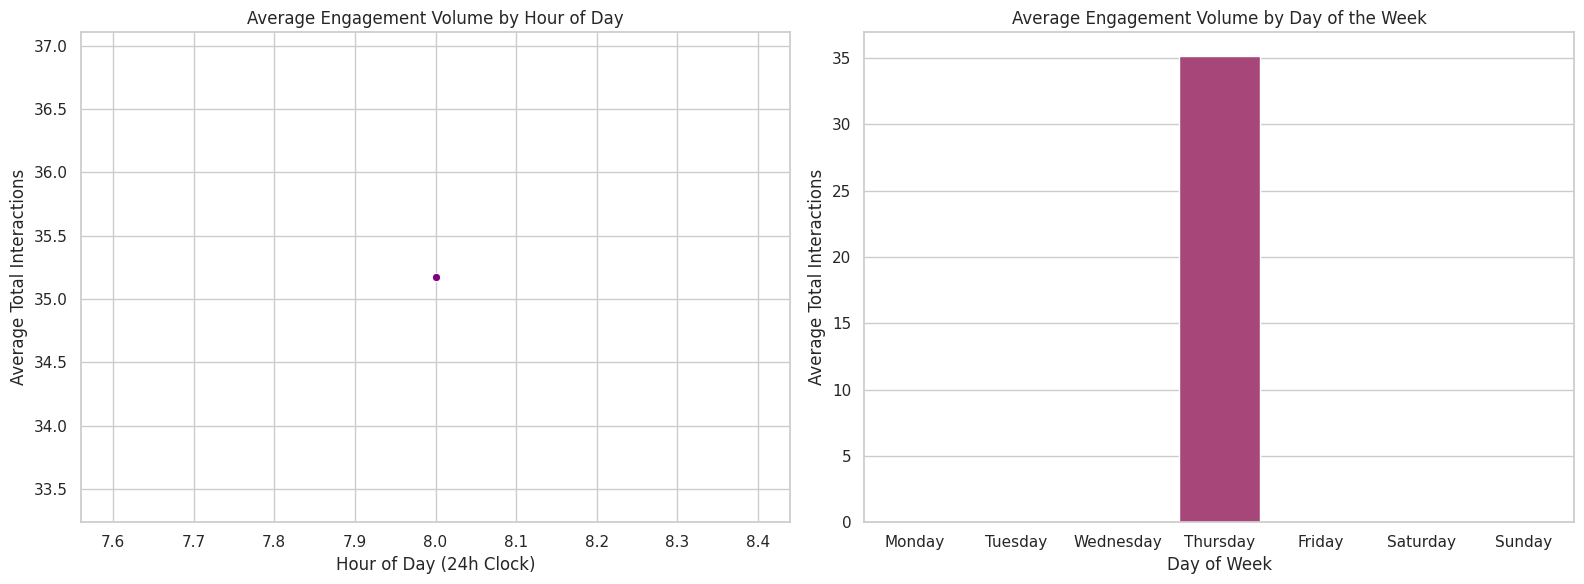

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Optimal Posting Windows by Hour
hourly_eng = df.groupby('hour')['total_engagement'].mean().reset_index()
sns.lineplot(ax=axes[0], data=hourly_eng, x='hour', y='total_engagement', marker='o', color='purple')
axes[0].set_title('Average Engagement Volume by Hour of Day')
axes[0].set_xlabel('Hour of Day (24h Clock)')
axes[0].set_ylabel('Average Total Interactions')

# Plot 2: Optimal Posting Days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(ax=axes[1], data=df, x='day_of_week', y='total_engagement', order=day_order, palette='magma', errorbar=None)
axes[1].set_title('Average Engagement Volume by Day of the Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Total Interactions')

plt.tight_layout()
plt.show()